In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.callbacks import ModelCheckpoint
import os

In [2]:
from tensorflow.keras.datasets import boston_housing

In [3]:
(X_train, y_train), (X_valid, y_valid) = boston_housing.load_data()

In [4]:
X_train.shape

(404, 13)

In [5]:
X_train[0]

array([  1.23247,   0.     ,   8.14   ,   0.     ,   0.538  ,   6.142  ,
        91.7    ,   3.9769 ,   4.     , 307.     ,  21.     , 396.9    ,
        18.72   ])

In [6]:
comatrix = np.corrcoef(X_train,rowvar=False)

In [7]:
comatrix.shape

(13, 13)

In [8]:
import seaborn as sns

<Axes: >

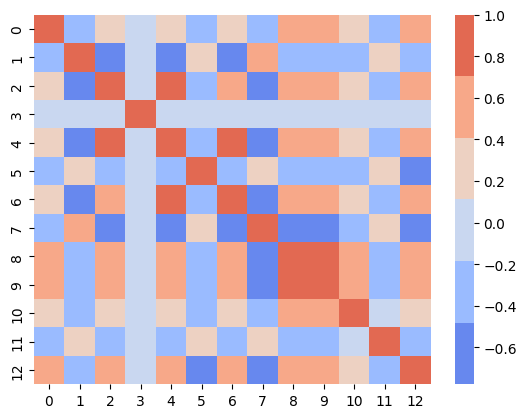

In [9]:
sns.heatmap(comatrix,cmap=sns.color_palette('coolwarm'))

<Axes: ylabel='Count'>

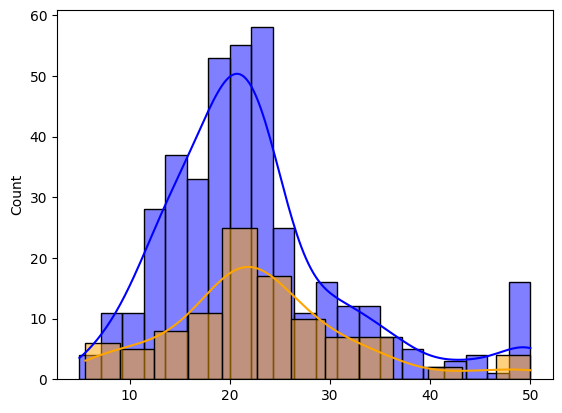

In [10]:
sns.histplot(y_train,color='blue',alpha=0.5,kde=True,label='y_train')
sns.histplot(y_valid,color='orange',alpha=0.5,kde=True,label='y_test')

##### Model Architecture

In [11]:
model = Sequential()

model.add(Dense(32,activation='relu', input_shape=(13,)))

model.add(Dense(16,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(1,activation='linear'))

c:\Users\keztan\workspace\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 32 (128.00 B)

In [13]:
model.compile(loss='mean_squared_error', optimizer='nadam')

In [14]:
output_dir = 'model_output/'

In [15]:
run_name = 'regression_baseline'
output_path = output_dir+run_name

In [16]:
if not os.path.exists(output_path):
    os.makedirs(output_path)

In [17]:
modelcheckpoint = ModelCheckpoint(output_path+'/weights_{epoch:02d}.weights.h5',save_weights_only=True)

Train

In [18]:
model.fit(X_train,y_train,batch_size=8,epochs=32,verbose=1,
          validation_data=(X_valid, y_valid),
          callbacks=[modelcheckpoint])

Epoch 1/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 595.2868 - val_loss: 529.7591
Epoch 2/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 564.1747 - val_loss: 672.3188
Epoch 3/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 545.1184 - val_loss: 621.1450
Epoch 4/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 504.6236 - val_loss: 526.8978
Epoch 5/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 465.2012 - val_loss: 493.5706
Epoch 6/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 497.1171 - val_loss: 463.8442
Epoch 7/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 374.8016 - val_loss: 424.7063
Epoch 8/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 355.5710 - val_loss: 377.4750
Epoch 9/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 335.2690 - val_loss: 375.0868
Epoch 10/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 285.1441 - val_loss: 317.7560
Epoch 11/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 260.6617 - val_loss: 335.8944
Epoch 12/32
51/51 ━━━━━━━━━━━━

Performance

In [19]:
model.load_weights(output_path+'/weights_28.weights.h5')

In [20]:
X_valid[42]

array([  9.32909,   0.     ,  18.1    ,   0.     ,   0.713  ,   6.185  ,
        98.7    ,   2.2616 ,  24.     , 666.     ,  20.2    , 396.9    ,
        18.13   ])

In [21]:
y_valid[42]

14.1

In [22]:
model.predict(np.reshape(X_valid[42],[1,13]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


array([[23.75117]], dtype=float32)

TensorBoard

In [23]:
from tensorflow.keras.callbacks import TensorBoard

In [25]:
model = Sequential()

model.add(Dense(32,activation='relu', input_shape=(13,)))

model.add(Dense(16,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(1,activation='linear'))

model.compile(loss='mean_squared_error', optimizer='nadam')

In [26]:
output_dir = 'model_output/'
run_name = 'regression_baseline'
output_path = output_dir+run_name
if not os.path.exists(output_path):
    os.makedirs(output_path)
    
modelcheckpoint = ModelCheckpoint(output_path+'/weights_{epoch:02d}.weights.h5',save_weights_only=True)

In [27]:
tensorboard = TensorBoard(log_dir='logs/' + run_name)

In [28]:
model.fit(X_train,y_train,
          batch_size=8, epochs=32,verbose=1,
          validation_data=(X_valid,y_valid),
          callbacks=[modelcheckpoint,tensorboard])

Epoch 1/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 554.5786 - val_loss: 636.2137
Epoch 2/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 549.9181 - val_loss: 623.4565
Epoch 3/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 536.1010 - val_loss: 613.5947
Epoch 4/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 519.6335 - val_loss: 591.4236
Epoch 5/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 499.1112 - val_loss: 518.3171
Epoch 6/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 463.8600 - val_loss: 461.5060
Epoch 7/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 394.4370 - val_loss: 390.4094
Epoch 8/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 342.2447 - val_loss: 326.0894
Epoch 9/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 327.1230 - val_loss: 291.3860
Epoch 10/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 316.5442 - val_loss: 279.7171
Epoch 11/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 251.7583 - val_loss: 233.3697
Epoch 12/32
51/51 ━━━━━━━━━━━

Another model architecture for comparison

In [30]:
model = Sequential()

model.add(Dense(32,activation='relu', input_shape=(13,)))

model.add(Dense(16,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(1,activation='linear'))

model.compile(loss='mean_squared_error', optimizer='nadam')

In [31]:
output_dir = 'model_output/'
run_name = 'regression_drop50'
output_path = output_dir+run_name
if not os.path.exists(output_path):
    os.makedirs(output_path)
    
modelcheckpoint = ModelCheckpoint(output_path+'/weights_{epoch:02d}.weights.h5',save_weights_only=True)

In [32]:
tensorboard = TensorBoard(log_dir='logs/' + run_name)

In [33]:
model.fit(X_train,y_train,
          batch_size=8, epochs=32,verbose=1,
          validation_data=(X_valid,y_valid),
          callbacks=[modelcheckpoint,tensorboard])

Epoch 1/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 571.9351 - val_loss: 718.7112
Epoch 2/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 549.0528 - val_loss: 645.0381
Epoch 3/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 583.1901 - val_loss: 605.7385
Epoch 4/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 571.4921 - val_loss: 566.6473
Epoch 5/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 510.0357 - val_loss: 530.7946
Epoch 6/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 509.5921 - val_loss: 495.2696
Epoch 7/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 441.7174 - val_loss: 466.4439
Epoch 8/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 402.2033 - val_loss: 422.5681
Epoch 9/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 362.4767 - val_loss: 396.6944
Epoch 10/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 371.9121 - val_loss: 344.9698
Epoch 11/32
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 298.1897 - val_loss: 308.7570
Epoch 12/32
51/51 ━━━━━━━━━━━